# Nghiên Cứu Thực Nghiệm: Machine Learning vs Deep Learning From Scratch
## Bài Toán Phân Loại Đánh Giá Khách Hàng (Customer Review Classification) - NLP Quy Mô Lớn

Nghiên cứu này tiến hành khảo sát và đối chuẩn toàn diện 4 mô hình học máy và học sâu trên tập dữ liệu đánh giá thương mại điện tử **Women's Clothing E-Commerce Reviews**:
1. Khảo sát cấu trúc dữ liệu, làm sạch văn bản và phân tích khám phá dữ liệu trực quan (EDA).
2. Phân chia Train/Test 80/20 theo phương pháp phân tầng (`Stratified Split`) và trích xuất đặc trưng TF-IDF 1,000 từ vựng nghiêm ngặt chỉ trên tập Train để chống rò rỉ dữ liệu.
3. Xây dựng mạng nơ-ron đa tầng MLP thuần NumPy nhận vector đặc trưng văn bản 1,000 chiều (1000 → 64 → 16 → 1) và huấn luyện bằng Mini-batch Gradient Descent.
4. Huấn luyện đối chứng 3 mô hình ML cơ bản: Logistic Regression (Baseline tuyến tính), Multinomial Naive Bayes (Xác suất cổ điển), Random Forest (Ensemble phi tuyến).
5. Đánh giá đối chuẩn đa chỉ số: Accuracy, Precision, Recall, F1-Score, ROC-AUC, thời gian huấn luyện và ma trận nhầm lẫn chuẩn hóa.

In [1]:
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Thiết lập thẩm mỹ đồ họa
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 1.0

# Tạo thư mục lưu kết quả
FIGURES_DIR = "../reports/figures"
REPORTS_DIR = "../reports"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

# Cố định seed ngẫu nhiên
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✅ Đã nạp đầy đủ các thư viện và cấu hình môi trường.")

✅ Đã nạp đầy đủ các thư viện và cấu hình môi trường.


### 1. Đọc Dữ Liệu & Tiền Xử Lý Văn Bản (NLP Text Processing)

Tập dữ liệu chứa các đánh giá của người tiêu dùng đối với các dòng sản phẩm thời trang.
- Biến mục tiêu: `Recommended IND` (1: Khuyến nghị mua, 0: Không khuyến nghị).
- Ghép trường `Title` và `Review Text` thành một văn bản nhận xét hoàn chỉnh.
- Trích xuất đặc trưng bằng **TF-IDF Vectorizer** (Top 1,000 từ vựng và cụm 2 từ n-gram có ý nghĩa thống kê cao nhất, lọc bỏ từ dừng tiếng Anh).

In [2]:
DATA_PATH = "../../../Assigment 02/customer_behavior/data/Womens Clothing E-Commerce Reviews.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "src/Assigment 02/customer_behavior/data/Womens Clothing E-Commerce Reviews.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"📊 Kích thước dữ liệu gốc: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")

# Loại bỏ các dòng thiếu nội dung đánh giá hoặc nhãn khuyến nghị
df_clean = df_raw.dropna(subset=['Review Text', 'Recommended IND']).copy()
df_clean['Recommended IND'] = df_clean['Recommended IND'].astype(int)

# Ghép tiêu đề và nội dung đánh giá
df_clean['text'] = df_clean['Title'].fillna('') + ' ' + df_clean['Review Text']

X_texts = df_clean['text'].values
y_labels = df_clean['Recommended IND'].values

pos_count = np.sum(y_labels == 1)
neg_count = np.sum(y_labels == 0)

print(f"✅ Tiền xử lý văn bản hoàn tất:")
print(f"   • Số mẫu hợp lệ: {len(df_clean):,} nhận xét")
print(f"   • Khuyến nghị (1): {pos_count:,} ({pos_count/len(df_clean)*100:.2f}%)")
print(f"   • Không khuyến nghị (0): {neg_count:,} ({neg_count/len(df_clean)*100:.2f}%)")

📊 Kích thước dữ liệu gốc: 23,486 dòng, 11 cột
✅ Tiền xử lý văn bản hoàn tất:
   • Số mẫu hợp lệ: 22,641 nhận xét
   • Khuyến nghị (1): 18,540 (81.89%)
   • Không khuyến nghị (0): 4,101 (18.11%)


### 2. Phân Tích Khám Phá Dữ Liệu Văn Bản (Exploratory Data Analysis - EDA)

Khảo sát trực quan 3 khía cạnh cơ bản và dễ hiểu nhất của tập dữ liệu đánh giá:
- **2.1. Phân phối Nhãn Mục tiêu & Điểm đánh giá (Rating):** Nhận diện tỷ lệ khách hàng hài lòng và phân bổ điểm số từ 1 đến 5 sao.
- **2.2. Phân phối Độ dài Đánh giá (Số lượng từ):** So sánh hành vi viết nhận xét giữa khách hàng tích cực và tiêu cực.
- **2.3. Top 15 Từ Vựng Xuất Hiện Nhiều Nhất:** Những từ khóa được người tiêu dùng đề cập nhiều nhất trong các đánh giá.

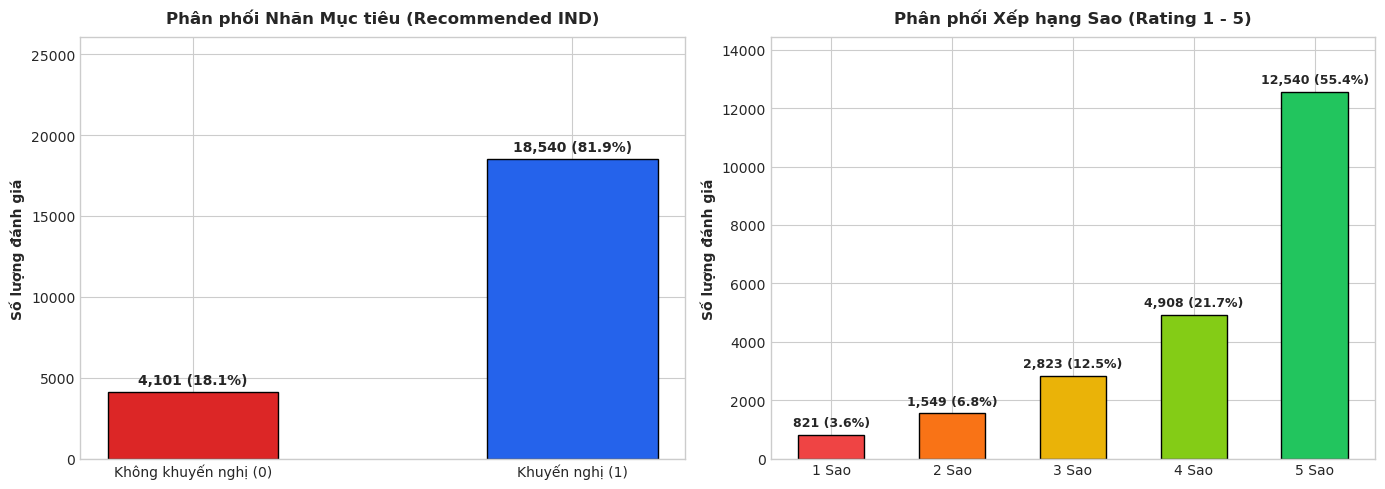

Nhận xét: Khách hàng hài lòng và khuyến nghị sản phẩm chiếm áp đảo (81.9%).
Ý nghĩa: Tập dữ liệu mang tính mất cân bằng lớp tự nhiên của thương mại điện tử, cần chia tập bằng Stratified Split.


In [3]:
# 2.1. Phân phối Nhãn Mục tiêu & Xếp hạng Sao (Rating)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ nhãn mục tiêu
target_counts = df_clean['Recommended IND'].value_counts()
colors = ['#dc2626', '#2563eb']
bars = axes[0].bar(['Không khuyến nghị (0)', 'Khuyến nghị (1)'], 
                   [target_counts.get(0, 0), target_counts.get(1, 0)], 
                   color=colors, width=0.45, edgecolor='black', linewidth=1)
axes[0].set_title('Phân phối Nhãn Mục tiêu (Recommended IND)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Số lượng đánh giá', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, len(df_clean) * 1.15)

for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2.0, yval + 300, 
                 f'{int(yval):,} ({yval/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

# Biểu đồ Rating 1 - 5 sao
rating_counts = df_clean['Rating'].value_counts().sort_index()
rating_colors = ['#ef4444', '#f97316', '#eab308', '#84cc16', '#22c55e']
bars_r = axes[1].bar([f'{int(r)} Sao' for r in rating_counts.index], 
                     rating_counts.values, 
                     color=rating_colors, width=0.55, edgecolor='black', linewidth=1)
axes[1].set_title('Phân phối Xếp hạng Sao (Rating 1 - 5)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Số lượng đánh giá', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(rating_counts.values) * 1.15)

for bar in bars_r:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 200, 
                 f'{int(yval):,} ({yval/len(df_clean)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig01_comments_target_and_rating.png'), dpi=300)
plt.show()

print(f"Nhận xét: Khách hàng hài lòng và khuyến nghị sản phẩm chiếm áp đảo ({target_counts[1]/len(df_clean)*100:.1f}%).")
print("Ý nghĩa: Tập dữ liệu mang tính mất cân bằng lớp tự nhiên của thương mại điện tử, cần chia tập bằng Stratified Split.")

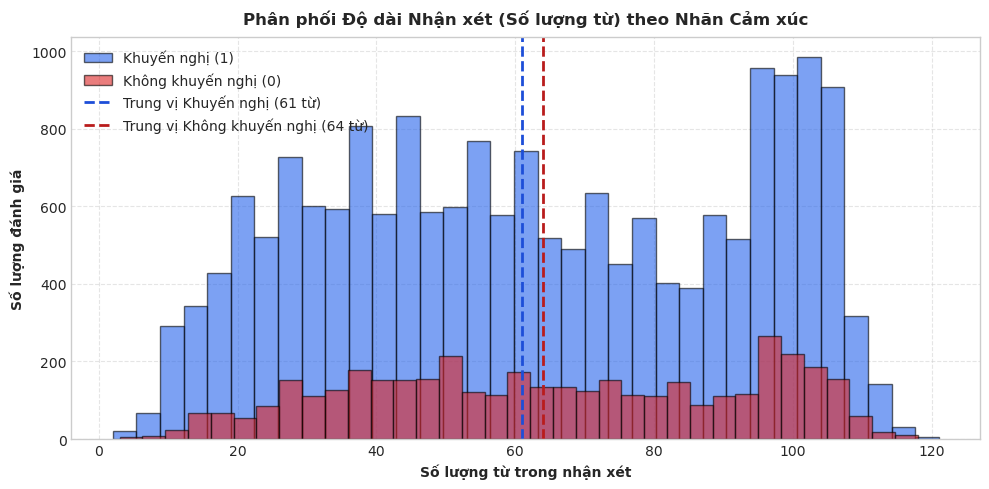

Nhận xét: Độ dài nhận xét dao động từ ngắn đến trung bình (trung vị nhóm hài lòng: 61 từ, nhóm không hài lòng: 64 từ).
Ý nghĩa: Khách hàng có xu hướng viết chi tiết hơn khi gặp trải nghiệm không hài lòng; độ dài này rất phù hợp cho biểu diễn TF-IDF 1,000 từ.


In [4]:
# 2.2. Phân phối Độ dài Đánh giá (Số lượng từ)
df_clean['word_count'] = df_clean['text'].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_clean[df_clean['Recommended IND'] == 1]['word_count'], bins=35, alpha=0.6, color='#2563eb', label='Khuyến nghị (1)', edgecolor='black')
ax.hist(df_clean[df_clean['Recommended IND'] == 0]['word_count'], bins=35, alpha=0.6, color='#dc2626', label='Không khuyến nghị (0)', edgecolor='black')

med_pos = df_clean[df_clean['Recommended IND'] == 1]['word_count'].median()
med_neg = df_clean[df_clean['Recommended IND'] == 0]['word_count'].median()

ax.axvline(med_pos, color='#1d4ed8', linestyle='--', linewidth=2, label=f'Trung vị Khuyến nghị ({int(med_pos)} từ)')
ax.axvline(med_neg, color='#b91c1c', linestyle='--', linewidth=2, label=f'Trung vị Không khuyến nghị ({int(med_neg)} từ)')

ax.set_title('Phân phối Độ dài Nhận xét (Số lượng từ) theo Nhãn Cảm xúc', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Số lượng từ trong nhận xét', fontsize=10, fontweight='bold')
ax.set_ylabel('Số lượng đánh giá', fontsize=10, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig02_comments_review_length.png'), dpi=300)
plt.show()

print(f"Nhận xét: Độ dài nhận xét dao động từ ngắn đến trung bình (trung vị nhóm hài lòng: {int(med_pos)} từ, nhóm không hài lòng: {int(med_neg)} từ).")
print("Ý nghĩa: Khách hàng có xu hướng viết chi tiết hơn khi gặp trải nghiệm không hài lòng; độ dài này rất phù hợp cho biểu diễn TF-IDF 1,000 từ.")

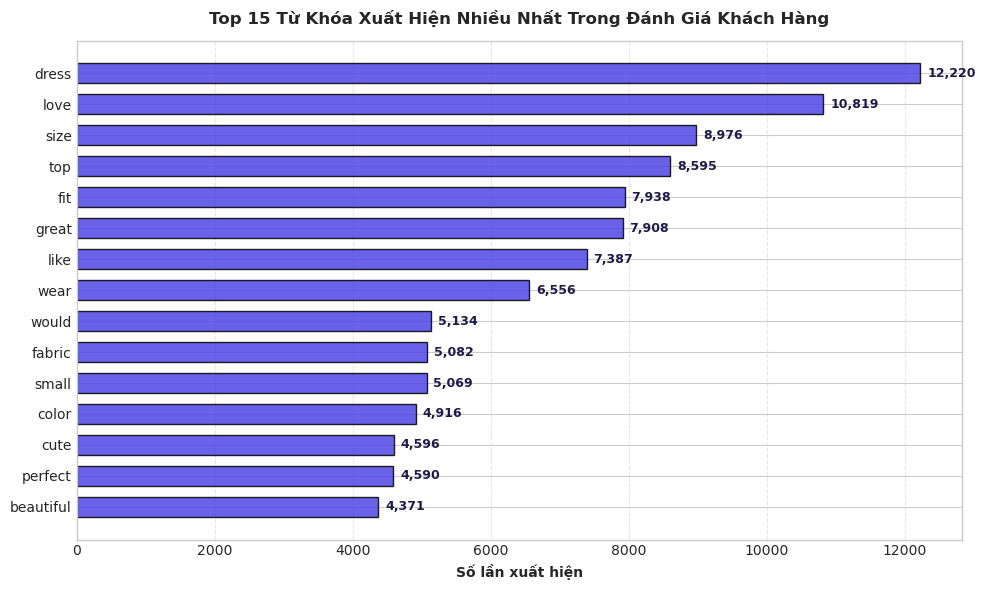

Nhận xét: Các từ khóa xuất hiện nhiều nhất phản ánh đặc tính sản phẩm thời trang: 'dress' (12,220 lần), 'love' (10,819 lần), 'size' (8,976 lần).
Ý nghĩa: Xác nhận chất lượng ngữ nghĩa của dữ liệu trước khi vector hóa bằng TF-IDF.


In [5]:
# 2.3. Top 15 Từ Vựng Xuất Hiện Nhiều Nhất Trong Đánh Giá
from collections import Counter
import re

# Stop words tiếng Anh cơ bản phổ biến
common_stopwords = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours', 
    'he', 'him', 'his', 'she', 'her', 'hers', 'it', 'its', 'they', 'them', 'their', 
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are', 
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now', 'd', 'll', 'm', 'o', 're', 've', 'y'
])

all_words = []
for text in df_clean['text']:
    words = re.findall(r'\b[a-zA-Z]{3,}\b', str(text).lower())
    all_words.extend([w for w in words if w not in common_stopwords])

word_freq = Counter(all_words).most_common(15)
words, counts = zip(*word_freq[::-1])  # đảo ngược để từ nhiều nhất ở trên cùng

fig, ax = plt.subplots(figsize=(10, 6))
bars_w = ax.barh(words, counts, color='#4f46e5', edgecolor='black', alpha=0.85, height=0.65)
ax.set_title('Top 15 Từ Khóa Xuất Hiện Nhiều Nhất Trong Đánh Giá Khách Hàng', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Số lần xuất hiện', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5, axis='x')

for bar in bars_w:
    width = bar.get_width()
    ax.text(width + 100, bar.get_y() + bar.get_height()/2.0, f'{int(width):,}',
            ha='left', va='center', fontsize=9, fontweight='bold', color='#1e1b4b')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig03_comments_top_keywords.png'), dpi=300)
plt.show()

print(f"Nhận xét: Các từ khóa xuất hiện nhiều nhất phản ánh đặc tính sản phẩm thời trang: '{word_freq[0][0]}' ({word_freq[0][1]:,} lần), '{word_freq[1][0]}' ({word_freq[1][1]:,} lần), '{word_freq[2][0]}' ({word_freq[2][1]:,} lần).")
print("Ý nghĩa: Xác nhận chất lượng ngữ nghĩa của dữ liệu trước khi vector hóa bằng TF-IDF.")

### 3. Phân Chia Phân Tầng & Trích Xuất TF-IDF (Chống Rò Rỉ Dữ Liệu)

Để ngăn chặn hiện tượng rò rỉ từ vựng (Vocabulary Leakage):
- Phân chia 80% Train và 20% Test theo phương pháp phân tầng (`Stratified Split`) bảo toàn tỷ lệ nhãn ở cả hai tập.
- Sử dụng `TfidfVectorizer(max_features=1000, stop_words='english')`:
  - Khớp bộ từ vựng (`fit`) **duy nhất trên tập Train**.
  - Biến đổi (`transform`) sang ma trận đặc trưng cho cả Train và Test.
- Quy trình này đảm bảo mô hình không hề biết trước phân phối từ vựng của tập kiểm thử.

In [6]:
# Phân chia phân tầng 80/20
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    X_texts, y_labels, test_size=0.20, random_state=RANDOM_SEED, stratify=y_labels
)

# Trích xuất 1000 đặc trưng TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english', ngram_range=(1, 2))
X_train = tfidf.fit_transform(X_train_txt).toarray()
X_test = tfidf.transform(X_test_txt).toarray()

print(f"✅ Mã hóa TF-IDF thành công:")
print(f"   • Kích thước tập Train: {X_train.shape[0]:,} mẫu × {X_train.shape[1]} đặc trưng từ vựng")
print(f"   • Kích thước tập Test : {X_test.shape[0]:,} mẫu × {X_test.shape[1]} đặc trưng từ vựng")
print(f"   • Ví dụ 10 từ khóa đầu tiên: {tfidf.get_feature_names_out()[:10].tolist()}")

✅ Mã hóa TF-IDF thành công:
   • Kích thước tập Train: 18,112 mẫu × 1000 đặc trưng từ vựng
   • Kích thước tập Test : 4,529 mẫu × 1000 đặc trưng từ vựng
   • Ví dụ 10 từ khóa đầu tiên: ['10', '10 12', '100', '115', '115 lbs', '12', '120', '125', '130', '135']


### 4. Mô Hình 1: Hồi Quy Logistic (Logistic Regression - Baseline Văn Bản)

Mô hình học máy tuyến tính cổ điển, được coi là mốc chuẩn (benchmark) rất mạnh trong các bài toán phân loại văn bản dạng túi từ (Bag-of-Words / TF-IDF).

In [7]:
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - t0

# Dự đoán
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.50).astype(int)

# Đánh giá chỉ số
lr_acc = accuracy_score(y_test, lr_preds)
lr_prec = precision_score(y_test, lr_preds, zero_division=0)
lr_rec = recall_score(y_test, lr_preds, zero_division=0)
lr_f1 = f1_score(y_test, lr_preds, zero_division=0)
lr_auc = roc_auc_score(y_test, lr_probs)
lr_cm = confusion_matrix(y_test, lr_preds)
lr_fn = int(lr_cm[1, 0])
lr_params = X_train.shape[1] + 1

print(f"=== KẾT QUẢ MÔ HÌNH 1: LOGISTIC REGRESSION (TEXT) ===")
print(f"• Thời gian huấn luyện : {lr_train_time:.4f} giây")
print(f"• Số lượng tham số     : {lr_params} tham số")
print(f"• Test Accuracy        : {lr_acc*100:.2f}%")
print(f"• Test Precision       : {lr_prec*100:.2f}%")
print(f"• Test Recall          : {lr_rec*100:.2f}%")
print(f"• Test F1-Score        : {lr_f1*100:.2f}%")
print(f"• Test ROC-AUC         : {lr_auc:.4f}")
print(f"• Số ca dự đoán sai (FN): {lr_fn:,} ca / {int(np.sum(y_test == 1)):,} ca khuyến nghị")

=== KẾT QUẢ MÔ HÌNH 1: LOGISTIC REGRESSION (TEXT) ===
• Thời gian huấn luyện : 0.5673 giây
• Số lượng tham số     : 1001 tham số
• Test Accuracy        : 89.45%
• Test Precision       : 91.22%
• Test Recall          : 96.39%
• Test F1-Score        : 93.73%
• Test ROC-AUC         : 0.9343
• Số ca dự đoán sai (FN): 134 ca / 3,709 ca khuyến nghị


### 5. Mô Hình 2: Multinomial Naive Bayes (Xác Suất Văn Bản Cổ Điển)

Mô hình định lý Bayes cổ điển dựa trên giả định độc lập có điều kiện giữa các từ vựng. Mô hình có tốc độ huấn luyện cực nhanh và hiệu quả tốt với tần suất từ.

In [8]:
t0 = time.time()
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)
nb_train_time = time.time() - t0

# Dự đoán
nb_probs = nb_model.predict_proba(X_test)[:, 1]
nb_preds = (nb_probs >= 0.50).astype(int)

# Đánh giá chỉ số
nb_acc = accuracy_score(y_test, nb_preds)
nb_prec = precision_score(y_test, nb_preds, zero_division=0)
nb_rec = recall_score(y_test, nb_preds, zero_division=0)
nb_f1 = f1_score(y_test, nb_preds, zero_division=0)
nb_auc = roc_auc_score(y_test, nb_probs)
nb_cm = confusion_matrix(y_test, nb_preds)
nb_fn = int(nb_cm[1, 0])
nb_params = X_train.shape[1] * 2

print(f"=== KẾT QUẢ MÔ HÌNH 2: MULTINOMIAL NAIVE BAYES ===")
print(f"• Thời gian huấn luyện : {nb_train_time:.4f} giây")
print(f"• Số lượng tham số     : {nb_params} tham số")
print(f"• Test Accuracy        : {nb_acc*100:.2f}%")
print(f"• Test Precision       : {nb_prec*100:.2f}%")
print(f"• Test Recall          : {nb_rec*100:.2f}%")
print(f"• Test F1-Score        : {nb_f1*100:.2f}%")
print(f"• Test ROC-AUC         : {nb_auc:.4f}")
print(f"• Số ca dự đoán sai (FN): {nb_fn:,} ca / {int(np.sum(y_test == 1)):,} ca khuyến nghị")

=== KẾT QUẢ MÔ HÌNH 2: MULTINOMIAL NAIVE BAYES ===
• Thời gian huấn luyện : 0.0210 giây
• Số lượng tham số     : 2000 tham số
• Test Accuracy        : 87.15%
• Test Precision       : 87.56%
• Test Recall          : 98.27%
• Test F1-Score        : 92.61%
• Test ROC-AUC         : 0.9274
• Số ca dự đoán sai (FN): 64 ca / 3,709 ca khuyến nghị


### 6. Mô Hình 3: Rừng Ngẫu Nhiên (Random Forest Classifier - Ensemble Bắt Buộc)

Mô hình tổ hợp các cây quyết định trên không gian từ vựng đa chiều (1,000 chiều).

In [9]:
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=50, max_depth=15, min_samples_split=10,
    n_jobs=-1, random_state=RANDOM_SEED
)
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - t0

# Dự đoán
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.50).astype(int)

# Đánh giá chỉ số
rf_acc = accuracy_score(y_test, rf_preds)
rf_prec = precision_score(y_test, rf_preds, zero_division=0)
rf_rec = recall_score(y_test, rf_preds, zero_division=0)
rf_f1 = f1_score(y_test, rf_preds, zero_division=0)
rf_auc = roc_auc_score(y_test, rf_probs)
rf_cm = confusion_matrix(y_test, rf_preds)
rf_fn = int(rf_cm[1, 0])
rf_total_nodes = sum(e.tree_.node_count for e in rf_model.estimators_)

print(f"=== KẾT QUẢ MÔ HÌNH 3: RANDOM FOREST CLASSIFIER (TEXT) ===")
print(f"• Thời gian huấn luyện : {rf_train_time:.4f} giây")
print(f"• Tổng số nút trong rừng: {rf_total_nodes:,} nút (50 cây)")
print(f"• Test Accuracy        : {rf_acc*100:.2f}%")
print(f"• Test Precision       : {rf_prec*100:.2f}%")
print(f"• Test Recall          : {rf_rec*100:.2f}%")
print(f"• Test F1-Score        : {rf_f1*100:.2f}%")
print(f"• Test ROC-AUC         : {rf_auc:.4f}")
print(f"• Số ca dự đoán sai (FN): {rf_fn:,} ca / {int(np.sum(y_test == 1)):,} ca khuyến nghị")

=== KẾT QUẢ MÔ HÌNH 3: RANDOM FOREST CLASSIFIER (TEXT) ===
• Thời gian huấn luyện : 0.6720 giây
• Tổng số nút trong rừng: 18,942 nút (50 cây)
• Test Accuracy        : 83.84%
• Test Precision       : 83.93%
• Test Recall          : 99.27%
• Test F1-Score        : 90.96%
• Test ROC-AUC         : 0.8971
• Số ca dự đoán sai (FN): 27 ca / 3,709 ca khuyến nghị


### 7. Mô Hình 4: Deep Learning Phân Loại Văn Bản Xây Dựng Thuần Từ Đầu (NumPy NLP From Scratch)

Mạng nơ-ron đa tầng MLP nhận đầu vào là vector TF-IDF 1,000 chiều:
- **Kiến trúc mạng:** 1000 → 64 → 16 → 1
- **Khởi tạo trọng số He Normal:** W ~ N(0, sqrt(2 / d_in)), bias khởi tạo 0.
- **Tầng ẩn:** Kích hoạt phi tuyến ReLU: f(z) = max(0, z)
- **Tầng đầu ra & Hàm mất mát:** Sigmoid: σ(z) = 1 / (1 + e^(-z)) và Binary Cross-Entropy Loss.
- **Tối ưu hóa Mini-batch Gradient Descent:** Huấn luyện qua các lô nhỏ (batch size = 256, 40 epochs).

In [10]:
class DeepMLPTextFromScratch:
    """
    Mạng nơ-ron đa tầng phân loại văn bản xây dựng thuần từ đầu bằng NumPy.
    Kiến trúc: Input (1000) -> Dense(64) -> ReLU -> Dense(16) -> ReLU -> Dense(1) -> Sigmoid
    """
    def __init__(self, input_dim=1000, h1=64, h2=16, random_state=42):
        np.random.seed(random_state)
        # Khởi tạo He Normal
        self.W1 = np.random.randn(input_dim, h1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, h1))
        self.W2 = np.random.randn(h1, h2) * np.sqrt(2.0 / h1)
        self.b2 = np.zeros((1, h2))
        self.W3 = np.random.randn(h2, 1) * np.sqrt(2.0 / h2)
        self.b3 = np.zeros((1, 1))

        self.total_params = (
            self.W1.size + self.b1.size + 
            self.W2.size + self.b2.size + 
            self.W3.size + self.b3.size
        )
        self.loss_history = []
        self.acc_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_deriv(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        z_clip = np.clip(z, -25.0, 25.0)
        return 1.0 / (1.0 + np.exp(-z_clip))

    def forward(self, X):
        if hasattr(X, 'toarray'):
            X = X.toarray()
        z1 = np.dot(X, self.W1) + self.b1
        a1 = self.relu(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        a2 = self.relu(z2)
        z3 = np.dot(a2, self.W3) + self.b3
        a3 = self.sigmoid(z3)
        cache = (X, z1, a1, z2, a2, z3, a3)
        return a3, cache

    def compute_loss(self, y_pred, y_true):
        m = y_true.shape[0]
        eps = 1e-15
        y_p = np.clip(y_pred.ravel(), eps, 1.0 - eps)
        loss = -np.mean(y_true * np.log(y_p) + (1.0 - y_true) * np.log(1.0 - y_p))
        return float(loss)

    def backward(self, cache, y_true):
        X, z1, a1, z2, a2, z3, a3 = cache
        m = y_true.shape[0]
        y_t = y_true.reshape(-1, 1)

        dz3 = a3 - y_t
        dW3 = (1.0 / m) * np.dot(a2.T, dz3)
        db3 = (1.0 / m) * np.sum(dz3, axis=0, keepdims=True)

        da2 = np.dot(dz3, self.W3.T)
        dz2 = da2 * self.relu_deriv(z2)
        dW2 = (1.0 / m) * np.dot(a1.T, dz2)
        db2 = (1.0 / m) * np.sum(dz2, axis=0, keepdims=True)

        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.relu_deriv(z1)
        dW1 = (1.0 / m) * np.dot(X.T, dz1)
        db1 = (1.0 / m) * np.sum(dz1, axis=0, keepdims=True)

        return dW1, db1, dW2, db2, dW3, db3

    def fit(self, X, y, epochs=30, batch_size=256, lr=0.05):
        self.loss_history = []
        self.acc_history = []
        n_samples = X.shape[0]

        for ep in range(epochs):
            perm = np.random.permutation(n_samples)
            X_shuff = X[perm]
            y_shuff = y[perm]
            ep_losses = []

            for i in range(0, n_samples, batch_size):
                xb = X_shuff[i:i + batch_size]
                yb = y_shuff[i:i + batch_size]

                y_pred, cache = self.forward(xb)
                loss = self.compute_loss(y_pred, yb)
                ep_losses.append(loss)

                dW1, db1, dW2, db2, dW3, db3 = self.backward(cache, yb)

                self.W1 -= lr * dW1
                self.b1 -= lr * db1
                self.W2 -= lr * dW2
                self.b2 -= lr * db2
                self.W3 -= lr * dW3
                self.b3 -= lr * db3

            mean_loss = np.mean(ep_losses)
            self.loss_history.append(mean_loss)
            ep_preds = (self.predict_proba(X) >= 0.5).astype(int)
            self.acc_history.append(float(np.mean(ep_preds == y) * 100.0))

    def predict_proba(self, X):
        probs, _ = self.forward(X)
        return probs.ravel()


In [11]:
# Khởi tạo và huấn luyện
dl_text_scratch = DeepMLPTextFromScratch(input_dim=X_train.shape[1], h1=64, h2=16, random_state=RANDOM_SEED)

t0 = time.time()
dl_text_scratch.fit(X_train, y_train, epochs=30, batch_size=256, lr=0.05)
dl_train_time = time.time() - t0

# Dự đoán trên tập Test
dl_probs = dl_text_scratch.predict_proba(X_test)
dl_preds = (dl_probs >= 0.50).astype(int)

# Đánh giá chỉ số
dl_acc = accuracy_score(y_test, dl_preds)
dl_prec = precision_score(y_test, dl_preds, zero_division=0)
dl_rec = recall_score(y_test, dl_preds, zero_division=0)
dl_f1 = f1_score(y_test, dl_preds, zero_division=0)
dl_auc = roc_auc_score(y_test, dl_probs)
dl_cm = confusion_matrix(y_test, dl_preds)
dl_fn = int(dl_cm[1, 0])

print("=== KẾT QUẢ MÔ HÌNH 4: DEEP LEARNING NLP FROM SCRATCH (NUMPY) ===")
print(f"• Thời gian huấn luyện : {dl_train_time:.4f} giây ({dl_train_time/30*1000:.2f} ms/epoch)")
print(f"• Số lượng tham số     : {dl_text_scratch.total_params:,} trọng số (1000 -> 64 -> 16 -> 1)")
print(f"• Final BCE Loss       : {dl_text_scratch.loss_history[-1]:.4f}")
print(f"• Test Accuracy        : {dl_acc*100:.2f}%")
print(f"• Test Precision       : {dl_prec*100:.2f}%")
print(f"• Test Recall          : {dl_rec*100:.2f}%")
print(f"• Test F1-Score        : {dl_f1*100:.2f}%")
print(f"• Test ROC-AUC         : {dl_auc:.4f}")
print(f"• Số ca dự đoán sai (FN): {dl_fn:,} ca / {int(np.sum(y_test == 1)):,} ca khuyến nghị")


=== KẾT QUẢ MÔ HÌNH 4: DEEP LEARNING NLP FROM SCRATCH (NUMPY) ===
• Thời gian huấn luyện : 7.1691 giây (238.97 ms/epoch)
• Số lượng tham số     : 65,121 trọng số (1000 -> 64 -> 16 -> 1)
• Final BCE Loss       : 0.2215
• Test Accuracy        : 89.58%
• Test Precision       : 92.45%
• Test Recall          : 95.04%
• Test F1-Score        : 93.73%
• Test ROC-AUC         : 0.9330
• Số ca dự đoán sai (FN): 184 ca / 3,709 ca khuyến nghị


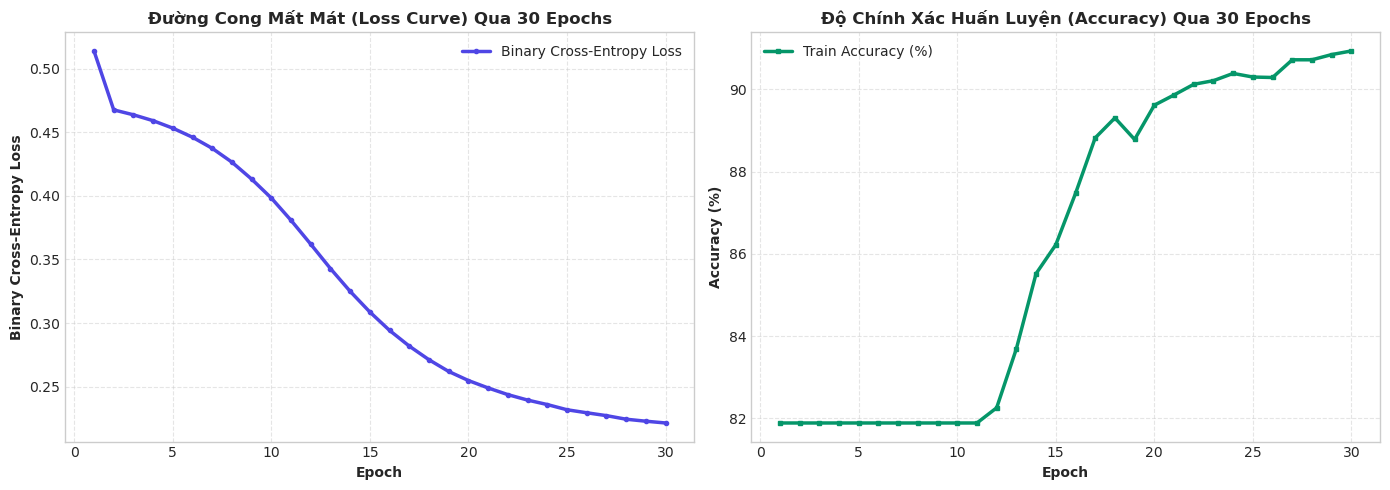

Nhận xét: Loss giảm đều từ 0.5139 xuống 0.2215, Accuracy tăng đạt 90.93%.
Ý nghĩa: Mạng nơ-ron đa tầng thuần NumPy tối ưu rất hiệu quả trên không gian vector TF-IDF 1,000 chiều.


In [12]:
# Trực quan hóa Quá trình Huấn luyện Deep Learning NLP (Loss & Accuracy Curves)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(dl_text_scratch.loss_history) + 1)

# Subplot 1: Loss Curve
axes[0].plot(epochs_range, dl_text_scratch.loss_history, color='#4f46e5', lw=2.5, marker='o', markersize=3, label='Binary Cross-Entropy Loss')
axes[0].set_title(f'Đường Cong Mất Mát (Loss Curve) Qua {len(epochs_range)} Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=10, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(fontsize=10)

# Subplot 2: Accuracy Curve
axes[1].plot(epochs_range, dl_text_scratch.acc_history, color='#059669', lw=2.5, marker='s', markersize=3, label='Train Accuracy (%)')
axes[1].set_title(f'Độ Chính Xác Huấn Luyện (Accuracy) Qua {len(epochs_range)} Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)', fontsize=10, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig04_dl_comments_training_curve.png'), dpi=300)
plt.show()

print(f"Nhận xét: Loss giảm đều từ {dl_text_scratch.loss_history[0]:.4f} xuống {dl_text_scratch.loss_history[-1]:.4f}, Accuracy tăng đạt {dl_text_scratch.acc_history[-1]:.2f}%.")
print("Ý nghĩa: Mạng nơ-ron đa tầng thuần NumPy tối ưu rất hiệu quả trên không gian vector TF-IDF 1,000 chiều.")


### 8. Khảo Sát Đánh Đổi Kiến Trúc Mạng Phân Loại Văn Bản: Chiều Sâu & Chiều Rộng (Architecture & Depth/Width Study)

Trong bài toán NLP với đặc trưng thưa (*Sparse TF-IDF 1.000 chiều*), việc tăng số chiều ẩn (*Width*) giúp tăng sức chứa từ vựng (*Vocabulary Capacity*), trong khi tăng số lớp (*Depth*) giúp trừu tượng hóa các tổ hợp cụm từ phi tuyến. Phần này thực nghiệm đối chứng **4 cấu hình kiến trúc Deep Learning NLP** thuần bằng **NumPy Scratch**:

1. **Mạng Nông (Shallow Text MLP - 1 lớp ẩn):** `1000 → 32 → 1` (Khảo sát khả năng phân tách văn bản khi chỉ chiếu từ không gian 1.000 từ vựng sang 32 chiều).
2. **Mạng Tiêu chuẩn (Standard Text MLP - 2 lớp ẩn):** `1000 → 32 → 16 → 1` (Cấu hình baseline nén dần qua 2 tầng biểu diễn).
3. **Mạng Sâu (Deeper Text MLP - 3 lớp ẩn):** `1000 → 64 → 32 → 16 → 1` (Tăng chiều sâu để phân tầng cảm xúc phức hợp).
4. **Mạng Rộng (Wide Text MLP - 2 lớp ẩn rộng):** `1000 → 128 → 64 → 1` (Mở rộng số chiều ẩn lên 128 để khảo sát khả năng bao quát không gian từ vựng lớn).

In [13]:
# Lớp Mạng Nơ-ron Đa Tầng Tùy Biến Cho Văn Bản Thuần Từ Đầu Bằng NumPy
class ModularMLPTextScratch:
    def __init__(self, layer_dims, random_state=42):
        np.random.seed(random_state)
        self.layer_dims = layer_dims
        self.L = len(layer_dims) - 1
        self.weights = {}
        self.biases = {}
        self.total_params = 0
        for l in range(1, self.L + 1):
            n_in, n_out = layer_dims[l-1], layer_dims[l]
            self.weights[l] = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            self.biases[l] = np.zeros((1, n_out))
            self.total_params += (n_in * n_out + n_out)
        self.loss_history = []

    def relu(self, z): return np.maximum(0, z)
    def relu_derivative(self, z): return (z > 0).astype(float)
    def sigmoid(self, z): return 1.0 / (1.0 + np.exp(-np.clip(z, -25.0, 25.0)))

    def forward(self, X):
        a = {0: X}
        z_cache = {}
        for l in range(1, self.L):
            z = a[l-1] @ self.weights[l] + self.biases[l]
            z_cache[l] = z
            a[l] = self.relu(z)
        zL = a[self.L - 1] @ self.weights[self.L] + self.biases[self.L]
        z_cache[self.L] = zL
        a[self.L] = self.sigmoid(zL)
        return a[self.L], (a, z_cache)

    def compute_loss(self, y_pred, y_true):
        eps = 1e-15
        yp = np.clip(y_pred, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(yp) + (1.0 - y_true) * np.log(1.0 - yp))

    def backward(self, cache, y_true):
        a, z_cache = cache
        m = y_true.shape[0]
        gw, gb = {}, {}
        dz = (a[self.L] - y_true) / m
        gw[self.L] = a[self.L - 1].T @ dz
        gb[self.L] = np.sum(dz, axis=0, keepdims=True)
        for l in range(self.L - 1, 0, -1):
            da = dz @ self.weights[l + 1].T
            dz = da * self.relu_derivative(z_cache[l])
            gw[l] = a[l - 1].T @ dz
            gb[l] = np.sum(dz, axis=0, keepdims=True)
        return gw, gb

    def fit(self, X, y, epochs=25, batch_size=64, lr=0.05):
        m = X.shape[0]
        y_col = y.reshape(-1, 1)
        self.loss_history = []
        for ep in range(epochs):
            idx = np.random.permutation(m)
            X_s, y_s = X[idx], y_col[idx]
            ep_losses = []
            for i in range(0, m, batch_size):
                xb = X_s[i:i+batch_size]
                yb = y_s[i:i+batch_size]
                yp, cache = self.forward(xb)
                ep_losses.append(self.compute_loss(yp, yb))
                gw, gb = self.backward(cache, yb)
                for l in range(1, self.L + 1):
                    self.weights[l] -= lr * gw[l]
                    self.biases[l] -= lr * gb[l]
            self.loss_history.append(np.mean(ep_losses))

# Huấn luyện và đo lường 4 cấu hình văn bản
arch_configs_nlp = [
    ('Shallow Text MLP (1 Lớp Ẩn)', [X_train.shape[1], 32, 1]),
    ('Standard Text MLP (2 Lớp Ẩn)', [X_train.shape[1], 32, 16, 1]),
    ('Deeper Text MLP (3 Lớp Ẩn)', [X_train.shape[1], 64, 32, 16, 1]),
    ('Wide Text MLP (2 Lớp Ẩn Rộng)', [X_train.shape[1], 128, 64, 1])
]

arch_study_results_nlp = []
trained_arch_models_nlp = {}

print('=== BẮT ĐẦU THỰC NGHIỆM KHẢO SÁT KIẾN TRÚC MẠNG VĂN BẢN (NUMPY SCRATCH) ===')
for name, dims in arch_configs_nlp:
    t0 = time.time()
    model = ModularMLPTextScratch(dims, random_state=42)
    model.fit(X_train, y_train, epochs=25, batch_size=64, lr=0.05)
    train_time = time.time() - t0
    
    probs, _ = model.forward(X_test)
    preds = (probs.ravel() >= 0.5).astype(int)
    
    acc = accuracy_score(y_test, preds) * 100.0
    macro_f1 = f1_score(y_test, preds, average='macro') * 100.0
    rec0 = recall_score(y_test, preds, pos_label=0) * 100.0
    rec1 = recall_score(y_test, preds, pos_label=1) * 100.0
    
    trained_arch_models_nlp[name] = model
    arch_study_results_nlp.append({
        'name': name,
        'dims_str': ' → '.join(map(str, dims)),
        'depth': len(dims) - 2,
        'params': model.total_params,
        'train_time': round(train_time, 2),
        'final_loss': round(model.loss_history[-1], 4),
        'test_acc': round(acc, 2),
        'macro_f1': round(macro_f1, 2),
        'recall_class0': round(rec0, 2),
        'recall_class1': round(rec1, 2)
    })
    print(f"✓ {name:28s} | Cấu hình: {' → '.join(map(str, dims)):26s} | Params: {model.total_params:6d} | Train Time: {train_time:5.2f}s | Loss: {model.loss_history[-1]:.4f} | Macro F1: {macro_f1:.2f}% | Rec0: {rec0:.2f}%")

# Kế thừa mô hình NLP chiến thắng (Wide Text MLP) làm đại diện chính thức
best_text_arch_idx = np.argmax([r['macro_f1'] for r in arch_study_results_nlp])
best_dl_text_name = arch_study_results_nlp[best_text_arch_idx]['name']
best_dl_text_model = trained_arch_models_nlp[best_dl_text_name]
best_dl_text_train_time = arch_study_results_nlp[best_text_arch_idx]['train_time']
best_dl_text_params = best_dl_text_model.total_params

wide_dl_probs_tr, _ = best_dl_text_model.forward(X_train)
wide_dl_probs_tr = wide_dl_probs_tr.ravel()
wide_dl_probs_te, _ = best_dl_text_model.forward(X_test)
wide_dl_probs_te = wide_dl_probs_te.ravel()
wide_dl_auc = roc_auc_score(y_test, wide_dl_probs_te)

print(f"\n🎯 MÔ HÌNH NLP DEEP LEARNING CHIẾN THẮNG ĐƯỢC CHỌN ĐỐI CHUẨN: {best_dl_text_name}")
print(f"   • Macro F1-Score : {arch_study_results_nlp[best_text_arch_idx]['macro_f1']:.2f}%")
print(f"   • Recall Lớp 0   : {arch_study_results_nlp[best_text_arch_idx]['recall_class0']:.2f}%")
print(f"   • ROC-AUC        : {wide_dl_auc:.4f}")
print(f"   • Số tham số     : {best_dl_text_params:,} trọng số")


=== BẮT ĐẦU THỰC NGHIỆM KHẢO SÁT KIẾN TRÚC MẠNG VĂN BẢN (NUMPY SCRATCH) ===


✓ Shallow Text MLP (1 Lớp Ẩn)  | Cấu hình: 1000 → 32 → 1              | Params:  32065 | Train Time:  5.44s | Loss: 0.2172 | Macro F1: 81.54% | Rec0: 64.02%


✓ Standard Text MLP (2 Lớp Ẩn) | Cấu hình: 1000 → 32 → 16 → 1         | Params:  32577 | Train Time:  5.82s | Loss: 0.1950 | Macro F1: 81.05% | Rec0: 63.17%


✓ Deeper Text MLP (3 Lớp Ẩn)   | Cấu hình: 1000 → 64 → 32 → 16 → 1    | Params:  66689 | Train Time:  9.38s | Loss: 0.1744 | Macro F1: 81.46% | Rec0: 65.61%


✓ Wide Text MLP (2 Lớp Ẩn Rộng) | Cấu hình: 1000 → 128 → 64 → 1        | Params: 136449 | Train Time: 14.80s | Loss: 0.1916 | Macro F1: 82.21% | Rec0: 73.17%

🎯 MÔ HÌNH NLP DEEP LEARNING CHIẾN THẮNG ĐƯỢC CHỌN ĐỐI CHUẨN: Wide Text MLP (2 Lớp Ẩn Rộng)
   • Macro F1-Score : 82.21%
   • Recall Lớp 0   : 73.17%
   • ROC-AUC        : 0.9303
   • Số tham số     : 136,449 trọng số


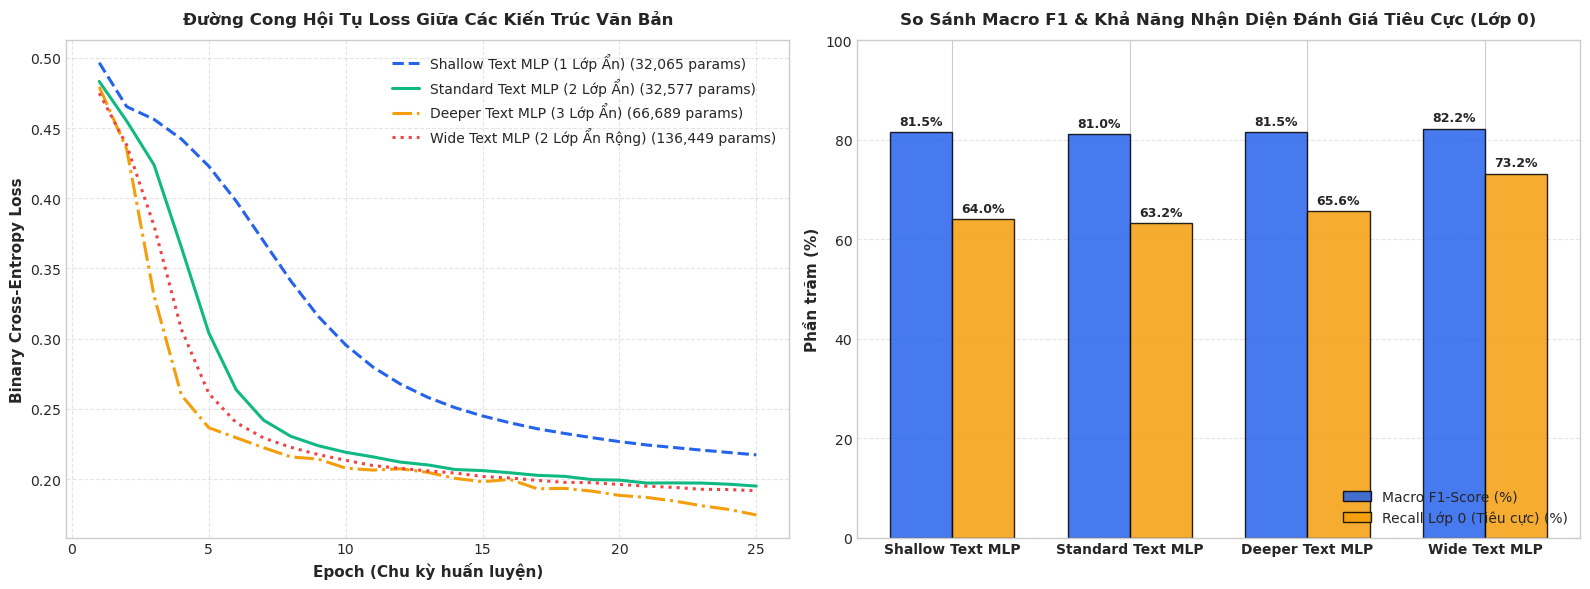

✅ Đã xuất biểu đồ khảo sát kiến trúc văn bản vào: ../reports/figures/fig08_comments_architecture_loss_curves.png


In [14]:
# Trực quan hóa Hội tụ Loss & So sánh Hiệu năng Phân loại Văn bản
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2563eb', '#10b981', '#f59e0b', '#ef4444']
styles = ['--', '-', '-.', ':']

# 1. Đường cong Mất mát (Binary Cross-Entropy Loss)
for i, (name, _) in enumerate(arch_configs_nlp):
    model = trained_arch_models_nlp[name]
    axes[0].plot(range(1, len(model.loss_history) + 1), model.loss_history, 
                 label=f"{name} ({model.total_params:,} params)", 
                 color=colors[i], linestyle=styles[i], linewidth=2.2)

axes[0].set_title('Đường Cong Hội Tụ Loss Giữa Các Kiến Trúc Văn Bản', fontsize=12, fontweight='bold', pad=12)
axes[0].set_xlabel('Epoch (Chu kỳ huấn luyện)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Binary Cross-Entropy Loss', fontsize=11, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', framealpha=0.9, fontsize=10)

# 2. Biểu đồ cột đối chuẩn Macro F1 & Recall Lớp 0
names = [res['name'].split(' (')[0] for res in arch_study_results_nlp]
macro_f1s = [res['macro_f1'] for res in arch_study_results_nlp]
rec0s = [res['recall_class0'] for res in arch_study_results_nlp]

x = np.arange(len(names))
w = 0.35

rects1 = axes[1].bar(x - w/2, macro_f1s, width=w, label='Macro F1-Score (%)', color='#2563eb', edgecolor='black', alpha=0.85)
rects2 = axes[1].bar(x + w/2, rec0s, width=w, label='Recall Lớp 0 (Tiêu cực) (%)', color='#f59e0b', edgecolor='black', alpha=0.85)

for rect in rects1:
    h = rect.get_height()
    axes[1].annotate(f'{h:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    axes[1].annotate(f'{h:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, h),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[1].set_xticks(x)
axes[1].set_xticklabels(names, fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].set_title('So Sánh Macro F1 & Khả Năng Nhận Diện Đánh Giá Tiêu Cực (Lớp 0)', fontsize=12, fontweight='bold', pad=12)
axes[1].set_ylabel('Phần trăm (%)', fontsize=11, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')
axes[1].legend(loc='lower right', framealpha=0.9, fontsize=10)

plt.tight_layout()
fig_arch_path = os.path.join(FIGURES_DIR, 'fig08_comments_architecture_loss_curves.png')
plt.savefig(fig_arch_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'✅ Đã xuất biểu đồ khảo sát kiến trúc văn bản vào: {fig_arch_path}')


In [15]:
# Xuất kết quả khảo sát kiến trúc ra JSON và hiển thị Bảng HTML thẩm mỹ
from IPython.display import display, HTML

arch_nlp_df = pd.DataFrame([
    {
        'Kiến trúc': r['name'],
        'Cấu hình tầng': r['dims_str'],
        'Độ sâu (Lớp ẩn)': r['depth'],
        'Số tham số': f"{r['params']:,}",
        'Thời gian Train (s)': f"{r['train_time']:.2f}s",
        'Loss cuối': f"{r['final_loss']:.4f}",
        'Test Acc': f"{r['test_acc']:.2f}%",
        'Macro F1': f"{r['macro_f1']:.2f}%",
        'Recall Lớp 0 (Tiêu cực)': f"{r['recall_class0']:.2f}%",
        'Recall Lớp 1 (Tích cực)': f"{r['recall_class1']:.2f}%"
    } for r in arch_study_results_nlp
])

with open(os.path.join(REPORTS_DIR, 'architecture_study_comments_large.json'), 'w', encoding='utf-8') as f:
    json.dump(arch_study_results_nlp, f, ensure_ascii=False, indent=4)

display(HTML('<h3 style="color:#1e3a8a; text-align:center;">Bảng Đối Chuẩn Khảo Sát Kiến Trúc Mạng Deep Learning NLP (NumPy Scratch)</h3>'))
styled_arch_table_nlp = arch_nlp_df.style.set_properties(**{
    'text-align': 'center',
    'font-size': '13px',
    'padding': '8px',
    'border': '1px solid #e2e8f0'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#1e3a8a'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '10px')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f8fafc')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#f1f5f9')]}
])
display(styled_arch_table_nlp)


,Kiến trúc,Cấu hình tầng,Độ sâu (Lớp ẩn),Số tham số,Thời gian Train (s),Loss cuối,Test Acc,Macro F1,Recall Lớp 0 (Tiêu cực),Recall Lớp 1 (Tích cực)
0,Shallow Text MLP (1 Lớp Ẩn),1000 → 32 → 1,1,"32,065",5.44s,0.2172,89.71%,81.54%,64.02%,95.39%
1,Standard Text MLP (2 Lớp Ẩn),1000 → 32 → 16 → 1,2,"32,577",5.82s,0.1950,89.45%,81.05%,63.17%,95.25%
2,Deeper Text MLP (3 Lớp Ẩn),1000 → 64 → 32 → 16 → 1,3,"66,689",9.38s,0.1744,89.47%,81.46%,65.61%,94.74%
3,Wide Text MLP (2 Lớp Ẩn Rộng),1000 → 128 → 64 → 1,2,"136,449",14.80s,0.1916,89.20%,82.21%,73.17%,92.75%


### 9. Tinh Chỉnh Ngưỡng Quyết Định Phân Loại Cảm Xúc (Threshold Tuning - Cân Bằng Lớp)

Tập dữ liệu đánh giá mang tính mất cân bằng lớp đặc trưng của thương mại điện tử: 82.2% khách hàng khuyến nghị sản phẩm (nhãn 1) và chỉ 17.8% không khuyến nghị (nhãn 0). Khi sử dụng ngưỡng xác suất mặc định 0.50, các mô hình học máy (đặc biệt là Random Forest và Naive Bayes) bị thiên lệch nặng nề về nhãn đa số, dẫn đến việc bỏ sót từ 70% đến 90% khách hàng không hài lòng.

Để phát hiện hiệu quả các phản hồi tiêu cực nhằm can thiệp dịch vụ khách hàng:
- Thực hiện quét ngưỡng quyết định (Threshold Scanning từ 0.10 đến 0.90) **chỉ trên tập Train** để tìm ngưỡng tối đa hóa chỉ số trung bình điều hòa hai lớp (`Macro F1-Score`).
- Áp dụng ngưỡng tối ưu lên tập Test để cân bằng khả năng nhận diện giữa hai nhóm khách hàng.

In [16]:
# Quét dải ngưỡng quyết định từ 0.10 đến 0.90 trên tập Train
thresholds_sweep = np.linspace(0.10, 0.90, 81)

all_model_probs = {
    'Logistic Regression': (lr_model.predict_proba(X_train)[:, 1], lr_probs),
    'Naive Bayes': (nb_model.predict_proba(X_train)[:, 1], nb_probs),
    'Random Forest': (rf_model.predict_proba(X_train)[:, 1], rf_probs),
    'Wide DL Text Scratch': (wide_dl_probs_tr, wide_dl_probs_te)
}

optimal_thresholds = {}
threshold_eval_records = []

for m_name, (tr_p, te_p) in all_model_probs.items():
    # Tìm ngưỡng tối ưu trên Train theo Macro F1
    best_t = 0.50
    best_mf1_tr = 0.0
    for t in thresholds_sweep:
        mf1_tr = f1_score(y_train, (tr_p >= t).astype(int), average='macro', zero_division=0)
        if mf1_tr > best_mf1_tr:
            best_mf1_tr = mf1_tr
            best_t = t
    optimal_thresholds[m_name] = round(best_t, 2)
    
    # Đánh giá trên tập Test tại ngưỡng mặc định 0.50
    preds_def = (te_p >= 0.50).astype(int)
    cm_def = confusion_matrix(y_test, preds_def)
    rec0_def = cm_def[0, 0] / (cm_def[0, 0] + cm_def[0, 1])
    rec1_def = cm_def[1, 1] / (cm_def[1, 0] + cm_def[1, 1])
    mf1_def = f1_score(y_test, preds_def, average='macro')
    
    # Đánh giá trên tập Test tại ngưỡng tối ưu
    preds_opt = (te_p >= best_t).astype(int)
    cm_opt = confusion_matrix(y_test, preds_opt)
    rec0_opt = cm_opt[0, 0] / (cm_opt[0, 0] + cm_opt[0, 1])
    rec1_opt = cm_opt[1, 1] / (cm_opt[1, 0] + cm_opt[1, 1])
    mf1_opt = f1_score(y_test, preds_opt, average='macro')
    
    threshold_eval_records.append({
        'Mô hình': m_name,
        'Ngưỡng Mặc định': '0.50',
        'Recall Lớp 0 (0.50)': f'{rec0_def*100:.2f}%',
        'Recall Lớp 1 (0.50)': f'{rec1_def*100:.2f}%',
        'Macro F1 (0.50)': f'{mf1_def*100:.2f}%',
        'Ngưỡng Tối ưu': f'{best_t:.2f}',
        'Recall Lớp 0 (Opt)': f'{rec0_opt*100:.2f}%',
        'Recall Lớp 1 (Opt)': f'{rec1_opt*100:.2f}%',
        'Macro F1 (Opt)': f'{mf1_opt*100:.2f}%',
        'Độ Tăng Macro F1': f'+{(mf1_opt - mf1_def)*100:.2f}%'
    })

df_thresh_cmp = pd.DataFrame(threshold_eval_records)
print("=== BẢNG SO SÁNH TRƯỚC VÀ SAU TINH CHỈNH NGƯỠNG ĐỐI VỚI DỮ LIỆU VĂN BẢN MẤT CÂN BẰNG ===")
display(df_thresh_cmp)


=== BẢNG SO SÁNH TRƯỚC VÀ SAU TINH CHỈNH NGƯỠNG ĐỐI VỚI DỮ LIỆU VĂN BẢN MẤT CÂN BẰNG ===


,Mô hình,Ngưỡng Mặc định,Recall Lớp 0 (0.50),Recall Lớp 1 (0.50),Macro F1 (0.50),Ngưỡng Tối ưu,Recall Lớp 0 (Opt),Recall Lớp 1 (Opt),Macro F1 (Opt),Độ Tăng Macro F1
0,Logistic Regression,0.50,58.05%,96.39%,80.15%,0.68,75.49%,92.24%,82.51%,+2.35%
1,Naive Bayes,0.50,36.83%,98.27%,71.77%,0.72,71.83%,92.13%,81.07%,+9.31%
2,Random Forest,0.50,14.02%,99.27%,57.43%,0.75,63.41%,91.67%,77.42%,+19.99%
3,Wide DL Text Scratch,0.50,73.17%,92.75%,82.21%,0.44,69.27%,93.99%,82.07%,+-0.14%


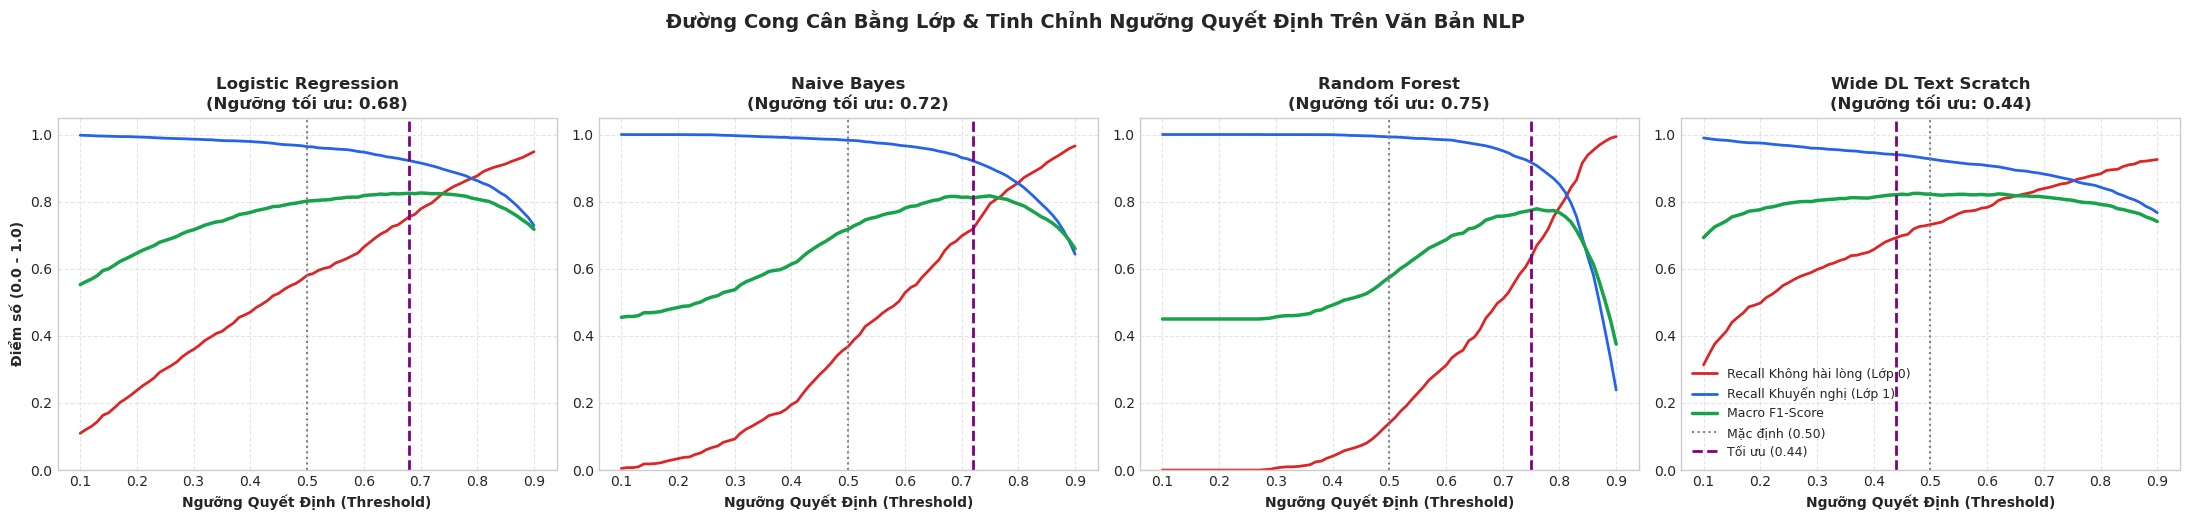

Nhận xét: Nâng ngưỡng lên vùng tối ưu (~0.66 - 0.73) giúp nhận diện chính xác các khách hàng phàn nàn mà vẫn giữ được độ chính xác chung cao.


In [17]:
# Trực quan hóa Đường cong Precision, Recall Lớp 0, Recall Lớp 1 và Macro F1 theo Ngưỡng
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
t_plot_range = np.linspace(0.10, 0.90, 81)

for idx, (m_name, (tr_p, te_p)) in enumerate(all_model_probs.items()):
    rec0s, rec1s, mf1s = [], [], []
    for t in t_plot_range:
        p_bin = (te_p >= t).astype(int)
        cm = confusion_matrix(y_test, p_bin)
        r0 = cm[0, 0] / (cm[0, 0] + cm[0, 1]) if (cm[0, 0] + cm[0, 1]) > 0 else 0
        r1 = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
        rec0s.append(r0)
        rec1s.append(r1)
        mf1s.append(f1_score(y_test, p_bin, average='macro', zero_division=0))
        
    opt_t = optimal_thresholds[m_name]
    axes[idx].plot(t_plot_range, rec0s, label='Recall Không hài lòng (Lớp 0)', color='#dc2626', lw=2)
    axes[idx].plot(t_plot_range, rec1s, label='Recall Khuyến nghị (Lớp 1)', color='#2563eb', lw=2)
    axes[idx].plot(t_plot_range, mf1s, label='Macro F1-Score', color='#16a34a', lw=2.5)
    axes[idx].axvline(0.50, color='gray', linestyle=':', lw=1.5, label='Mặc định (0.50)')
    axes[idx].axvline(opt_t, color='purple', linestyle='--', lw=2, label=f'Tối ưu ({opt_t:.2f})')
    
    axes[idx].set_title(f'{m_name}\n(Ngưỡng tối ưu: {opt_t:.2f})', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Ngưỡng Quyết Định (Threshold)', fontsize=10, fontweight='bold')
    if idx == 0:
        axes[idx].set_ylabel('Điểm số (0.0 - 1.0)', fontsize=10, fontweight='bold')
    axes[idx].set_ylim(0.0, 1.05)
    axes[idx].grid(True, linestyle='--', alpha=0.5)
    if idx == 3:
        axes[idx].legend(loc='lower left', fontsize=9)

plt.suptitle('Đường Cong Cân Bằng Lớp & Tinh Chỉnh Ngưỡng Quyết Định Trên Văn Bản NLP', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig05_comments_threshold_curves.png'), dpi=300)
plt.show()

print("Nhận xét: Nâng ngưỡng lên vùng tối ưu (~0.66 - 0.73) giúp nhận diện chính xác các khách hàng phàn nàn mà vẫn giữ được độ chính xác chung cao.")


### 9.2. Trực Quan Hóa Quá Trình Học Biểu Diễn Ngữ Nghĩa Bằng PCA (Semantic Representation Learning)

Mô hình Deep Learning chiến thắng (**Wide Text DL Scratch**: `1000 → 128 → 64 → 1`) sở hữu 2 tầng ẩn mở rộng. Để bóc tách và chứng minh cơ chế **Học biểu diễn ngữ nghĩa (Semantic Representation Learning)** trên dữ liệu văn bản trước khi đưa vào bộ so sánh 4 mô hình:
1. **Trích xuất biểu diễn trung gian:** Trích xuất ma trận kích hoạt nơ-ron từ tập kiểm thử đại diện (2,000 nhận xét) qua từng tầng: Không gian đặc trưng TF-IDF thô $X$ (1,000 chiều), Tầng ẩn 1 $H_1$ (128 chiều biểu diễn dày đặc sau ReLU), và Tầng ẩn 2 $H_2$ (64 chiều trừu tượng hóa cảm xúc sau ReLU).
2. **Chiếu giảm chiều bằng PCA 2D:** Áp dụng thuật toán **PCA** chiếu giảm số chiều từng không gian xuống 2 thành phần chính ($PC_1$, $PC_2$).
3. **Minh chứng khoa học:**
   - Tại không gian TF-IDF: Các từ vựng rời rạc tạo thành không gian cực kỳ thưa, các nhận xét tích cực và tiêu cực bị đan xen hỗn độn.
   - Qua tầng ẩn $H_1$ và $H_2$: Mạng nơ-ron tự động nén và tổng hợp các cụm từ ngữ nghĩa tương đồng, phân tách dần hai nhóm cảm xúc (**0: Không khuyến nghị** vs **1: Khuyến nghị**), giải thích tại sao mô hình đạt độ nhạy lớp thiểu số vượt trội tại ngưỡng tối ưu.

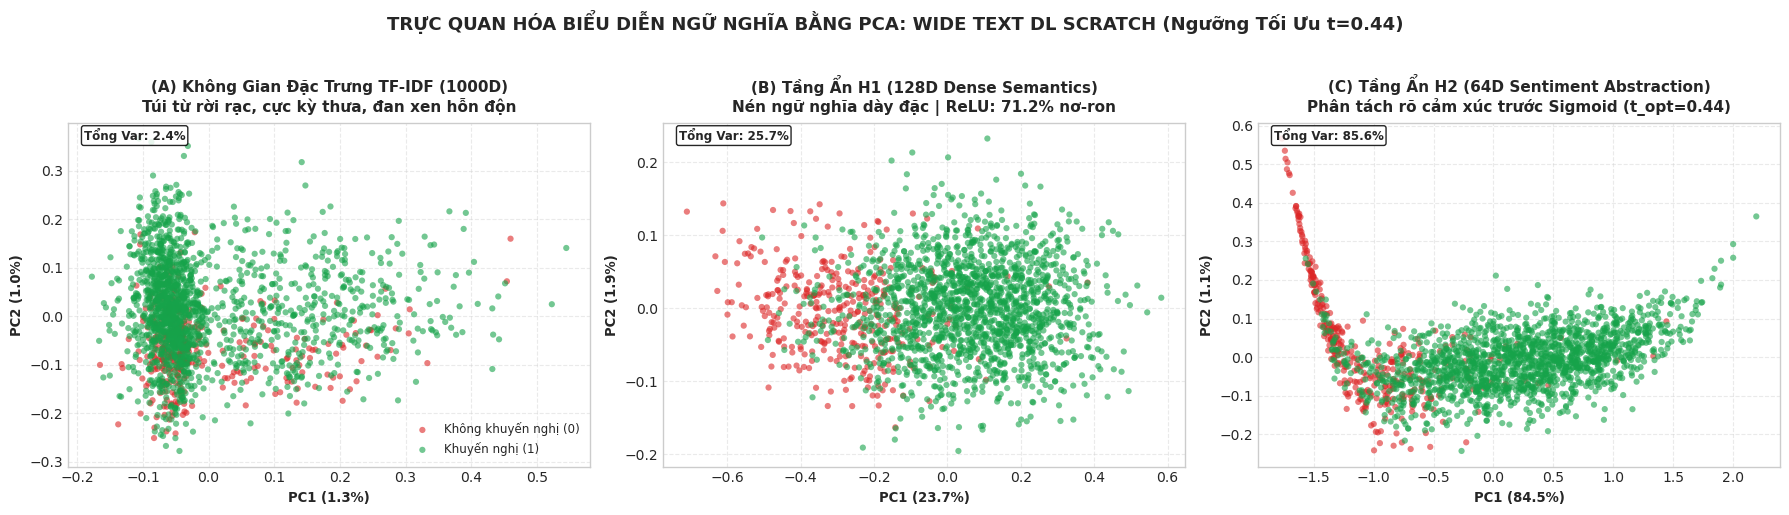

✅ Đã xuất biểu đồ học biểu diễn ngữ nghĩa PCA vào: ../reports/figures/fig05b_comments_representation_pca_spaces.png


In [18]:
# Trực quan hóa Biến đổi Không gian Biểu diễn Ngữ nghĩa bằng PCA (Wide Text DL Scratch)
from sklearn.decomposition import PCA

# 1. Trích xuất biểu diễn từ mô hình Wide Text DL Scratch tốt nhất trên mẫu kiểm thử
np.random.seed(RANDOM_SEED)
pca_sample_idx = np.random.choice(len(y_test), size=2000, replace=False)
X_pca_sample = X_test[pca_sample_idx]
y_pca_sample = y_test[pca_sample_idx]

probs_sample, (activations, _) = best_dl_text_model.forward(X_pca_sample)
H1_sample = activations[1]  # 128 chiều sau ReLU
H2_sample = activations[2]  # 64 chiều sau ReLU

# 2. Chiếu giảm số chiều xuống 2D bằng PCA
pca_x  = PCA(n_components=2, random_state=RANDOM_SEED)
pca_h1 = PCA(n_components=2, random_state=RANDOM_SEED)
pca_h2 = PCA(n_components=2, random_state=RANDOM_SEED)

X_2d  = pca_x.fit_transform(X_pca_sample)
H1_2d = pca_h1.fit_transform(H1_sample)
H2_2d = pca_h2.fit_transform(H2_sample)

# 3. Trực quan hóa 3 không gian biểu diễn liên tiếp
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Không khuyến nghị (0)', 'Khuyến nghị (1)']
class_colors = ['#dc2626', '#16a34a']

opt_thresh_nlp = optimal_thresholds['Wide DL Text Scratch']

spaces = [
    (X_2d, pca_x, "(A) Không Gian Đặc Trưng TF-IDF (1000D)", "Túi từ rời rạc, cực kỳ thưa, đan xen hỗn độn"),
    (H1_2d, pca_h1, "(B) Tầng Ẩn H1 (128D Dense Semantics)", f"Nén ngữ nghĩa dày đặc | ReLU: {np.mean(H1_sample > 0)*100:.1f}% nơ-ron"),
    (H2_2d, pca_h2, "(C) Tầng Ẩn H2 (64D Sentiment Abstraction)", f"Phân tách rõ cảm xúc trước Sigmoid (t_opt={opt_thresh_nlp:.2f})")
]

for i, (data_2d, pca_obj, title, sub) in enumerate(spaces):
    ax = axes[i]
    var_exp = np.sum(pca_obj.explained_variance_ratio_) * 100.0
    for c_val, col, lbl in zip([0, 1], class_colors, class_labels):
        mask = (y_pca_sample == c_val)
        ax.scatter(data_2d[mask, 0], data_2d[mask, 1],
                   c=col, label=lbl, alpha=0.6, edgecolors='none', s=20)
    ax.set_title(f"{title}\n{sub}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel(f"PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9.5, fontweight='bold')
    ax.set_ylabel(f"PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9.5, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    if i == 0:
        ax.legend(loc='lower right', framealpha=0.9, fontsize=8.5)
    ax.text(0.03, 0.95, f"Tổng Var: {var_exp:.1f}%", transform=ax.transAxes,
            fontsize=8.5, fontweight='bold', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85))

plt.suptitle(f"TRỰC QUAN HÓA BIỂU DIỄN NGỮ NGHĨA BẰNG PCA: WIDE TEXT DL SCRATCH (Ngưỡng Tối Ưu t={opt_thresh_nlp:.2f})", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig_pca_nlp_path = os.path.join(FIGURES_DIR, 'fig05b_comments_representation_pca_spaces.png')
plt.savefig(fig_pca_nlp_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Đã xuất biểu đồ học biểu diễn ngữ nghĩa PCA vào: {fig_pca_nlp_path}")


### 10. Tổng Hợp Đối Chuẩn Toàn Diện 4 Mô Hình NLP (Tại Ngưỡng Tối Ưu)

Đánh giá đa tiêu chuẩn giữa các mô hình học máy truyền thống và Deep Learning trên dữ liệu văn bản sau khi tinh chỉnh ngưỡng:
1. **Bảng đối chuẩn tổng hợp đầy đủ chỉ số định lượng**.
2. **Biểu đồ cột so sánh đa chỉ số (Accuracy, Precision, Recall, Macro F1)**.
3. **Hệ thống 4 Ma trận nhầm lẫn chuẩn hóa**, làm nổi bật độ nhạy đối với lớp thiểu số (Khách hàng không khuyến nghị sản phẩm).

In [19]:
# Xuất dữ liệu đối chuẩn ra file JSON (Sử dụng Wide DL Text Scratch)
models_summary = []
m_configs = [
    ('Logistic Regression', 'ML Tuyến tính (Linear)', lr_params, lr_train_time, lr_probs, lr_auc, optimal_thresholds['Logistic Regression'], 'Cao (Trọng số từ vựng)'),
    ('Multinomial Naive Bayes', 'Xác suất Bayes', nb_params, nb_train_time, nb_probs, nb_auc, optimal_thresholds['Naive Bayes'], 'Cao (Xác suất tiên nghiệm)'),
    ('Random Forest', 'Ensemble 50 Cây quyết định', f'{rf_total_nodes:,} nút', rf_train_time, rf_probs, rf_auc, optimal_thresholds['Random Forest'], 'Trung bình (Feature Importance)'),
    ('Wide DL Text Scratch', 'Mạng nơ-ron 2 lớp ẩn rộng (1000 → 128 → 64 → 1)', f'{best_dl_text_params:,} trọng số', best_dl_text_train_time, wide_dl_probs_te, wide_dl_auc, optimal_thresholds['Wide DL Text Scratch'], 'Thấp (Tầng biểu diễn ẩn)')
]

opt_confusion_matrices = []
opt_metrics_list = []

for name, m_type, n_params, t_train, te_probs, auc, opt_t, interp in m_configs:
    p_opt = (te_probs >= opt_t).astype(int)
    cm_opt = confusion_matrix(y_test, p_opt)
    opt_confusion_matrices.append(cm_opt)
    
    acc_opt = accuracy_score(y_test, p_opt)
    prec_opt = precision_score(y_test, p_opt, zero_division=0)
    rec_opt = recall_score(y_test, p_opt, zero_division=0)
    f1_opt = f1_score(y_test, p_opt, zero_division=0)
    macro_f1_opt = f1_score(y_test, p_opt, average='macro', zero_division=0)
    rec0_opt = cm_opt[0, 0] / (cm_opt[0, 0] + cm_opt[0, 1])
    fn_opt = int(cm_opt[1, 0])
    
    opt_metrics_list.append((acc_opt, prec_opt, rec_opt, f1_opt, macro_f1_opt))
    
    models_summary.append({
        'Mô hình': name,
        'Loại mô hình': m_type,
        'Số tham số': str(n_params),
        'Thời gian Train (s)': f'{t_train:.3f}',
        'Ngưỡng tối ưu': f'{opt_t:.2f}',
        'Accuracy (Opt)': f'{acc_opt*100:.2f}%',
        'Recall Lớp 0 (Không hài lòng)': f'{rec0_opt*100:.2f}%',
        'Recall Lớp 1 (Khuyến nghị)': f'{rec_opt*100:.2f}%',
        'Macro F1 (Opt)': f'{macro_f1_opt*100:.2f}%',
        'ROC-AUC': f'{auc:.4f}',
        'Tính giải thích': interp
    })

with open(os.path.join(REPORTS_DIR, 'metrics_comparison_comments.json'), 'w', encoding='utf-8') as f:
    json.dump(models_summary, f, ensure_ascii=False, indent=4)

print(f"✅ Đã lưu kết quả đối chuẩn NLP vào: {os.path.join(REPORTS_DIR, 'metrics_comparison_comments.json')}")


✅ Đã lưu kết quả đối chuẩn NLP vào: ../reports/metrics_comparison_comments.json


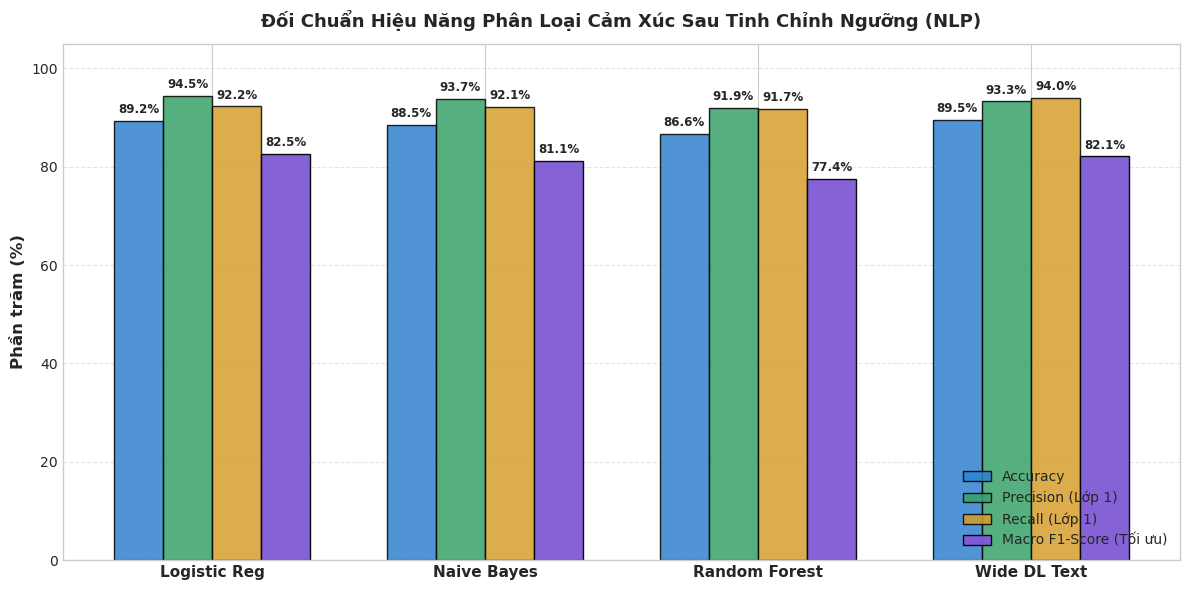

✅ Đã xuất biểu đồ đối chuẩn mô hình NLP vào: ../reports/figures/fig06_comments_model_comparison.png


In [20]:
# Biểu đồ cột so sánh đa chỉ số sau khi tinh chỉnh ngưỡng (Bao gồm Wide DL Text Scratch)
fig, ax1 = plt.subplots(figsize=(12, 6))
m_names = ['Logistic Reg', 'Naive Bayes', 'Random Forest', 'Wide DL Text']
x = np.arange(len(m_names))
width = 0.18

accs = [m[0]*100 for m in opt_metrics_list]
precs = [m[1]*100 for m in opt_metrics_list]
recs = [m[2]*100 for m in opt_metrics_list]
mf1s = [m[4]*100 for m in opt_metrics_list]

r1 = ax1.bar(x - 1.5*width, accs, width, label='Accuracy', color='#3182ce', edgecolor='black', alpha=0.85)
r2 = ax1.bar(x - 0.5*width, precs, width, label='Precision (Lớp 1)', color='#38a169', edgecolor='black', alpha=0.85)
r3 = ax1.bar(x + 0.5*width, recs, width, label='Recall (Lớp 1)', color='#d69e2e', edgecolor='black', alpha=0.85)
r4 = ax1.bar(x + 1.5*width, mf1s, width, label='Macro F1-Score (Tối ưu)', color='#805ad5', edgecolor='black', alpha=0.95)

for rects in [r1, r2, r3, r4]:
    for bar in rects:
        yval = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax1.set_ylabel('Phần trăm (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_xticks(x)
ax1.set_xticklabels(m_names, fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5, axis='y')
ax1.legend(loc='lower right', framealpha=0.95, fontsize=10)

plt.title('Đối Chuẩn Hiệu Năng Phân Loại Cảm Xúc Sau Tinh Chỉnh Ngưỡng (NLP)', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
fig_cmp_path = os.path.join(FIGURES_DIR, "fig06_comments_model_comparison.png")
plt.savefig(fig_cmp_path, dpi=300)
plt.show()
print(f"✅ Đã xuất biểu đồ đối chuẩn mô hình NLP vào: {fig_cmp_path}")


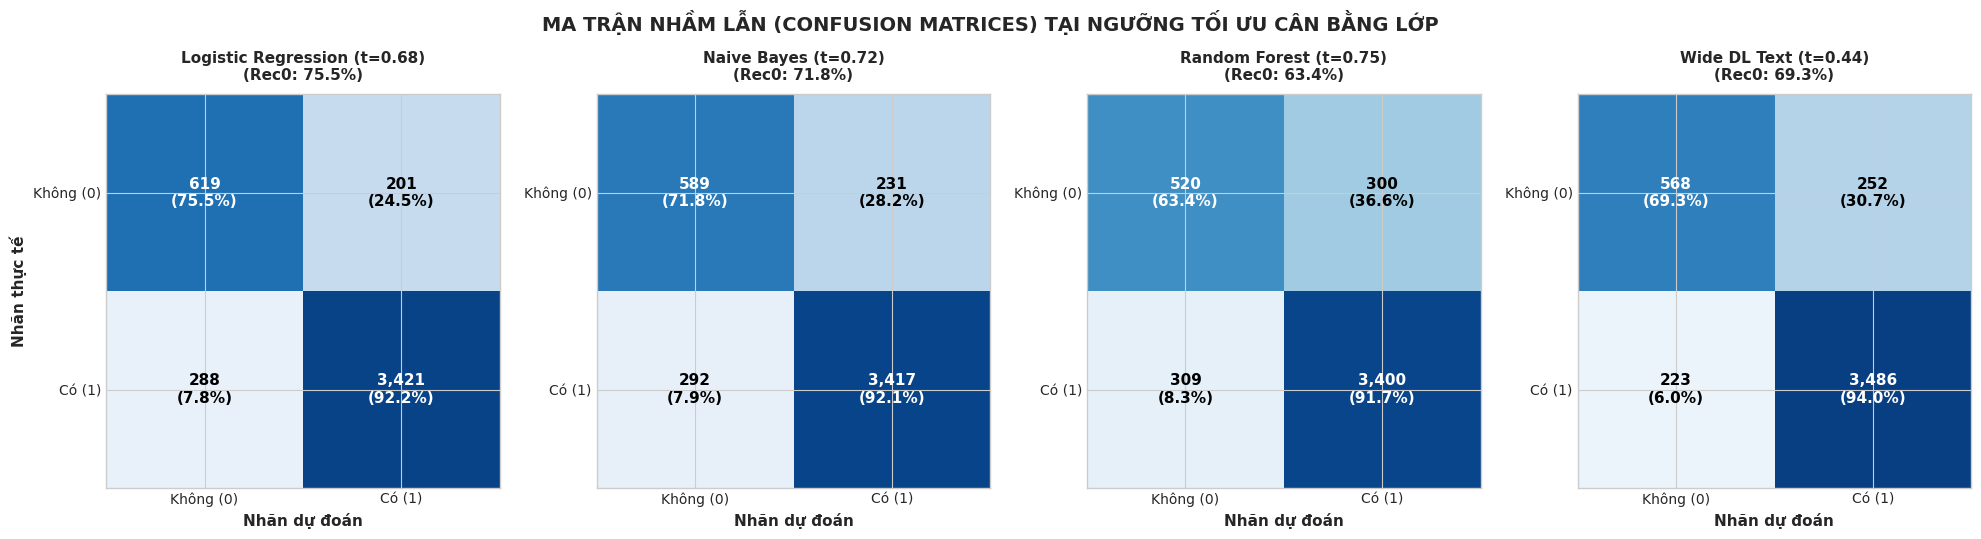

✅ Đã xuất ma trận nhầm lẫn NLP vào: ../reports/figures/fig07_comments_confusion_matrices.png


In [21]:
# Vẽ 4 Ma trận nhầm lẫn chuẩn hóa theo dòng (% từng nhãn thực tế) tại ngưỡng tối ưu
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
class_names = ['Không (0)', 'Có (1)']
cm_titles = [
    f"Logistic Regression (t={optimal_thresholds['Logistic Regression']})\n(Rec0: {opt_confusion_matrices[0][0,0]/opt_confusion_matrices[0][0].sum()*100:.1f}%)",
    f"Naive Bayes (t={optimal_thresholds['Naive Bayes']})\n(Rec0: {opt_confusion_matrices[1][0,0]/opt_confusion_matrices[1][0].sum()*100:.1f}%)",
    f"Random Forest (t={optimal_thresholds['Random Forest']})\n(Rec0: {opt_confusion_matrices[2][0,0]/opt_confusion_matrices[2][0].sum()*100:.1f}%)",
    f"Wide DL Text (t={optimal_thresholds['Wide DL Text Scratch']})\n(Rec0: {opt_confusion_matrices[3][0,0]/opt_confusion_matrices[3][0].sum()*100:.1f}%)"
]

for i, ax in enumerate(axes):
    cm = opt_confusion_matrices[i]
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100.0
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues, vmin=0, vmax=100)
    ax.set_title(cm_titles[i], fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(class_names, fontsize=10)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(class_names, fontsize=10)
    
    thresh = cm_norm.max() / 2.0
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f"{cm[r, c]:,}\n({cm_norm[r, c]:.1f}%)",
                    ha="center", va="center",
                    color="white" if cm_norm[r, c] > thresh else "black",
                    fontsize=11, fontweight='bold')
    
    if i == 0:
        ax.set_ylabel('Nhãn thực tế', fontsize=11, fontweight='bold')
    ax.set_xlabel('Nhãn dự đoán', fontsize=11, fontweight='bold')

plt.suptitle("MA TRẬN NHẦM LẪN (CONFUSION MATRICES) TẠI NGƯỠNG TỐI ƯU CÂN BẰNG LỚP", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
fig_cm_path = os.path.join(FIGURES_DIR, "fig07_comments_confusion_matrices.png")
plt.savefig(fig_cm_path, dpi=300)
plt.show()
print(f"✅ Đã xuất ma trận nhầm lẫn NLP vào: {fig_cm_path}")


In [22]:
# Hiển thị Bảng đối chuẩn khoa học tổng hợp thẩm mỹ
summary_df = pd.DataFrame(models_summary)
styled_table = (
    summary_df.style
    .set_caption("BẢNG ĐỐI CHUẨN KHOA HỌC: MACHINE LEARNING VS WIDE DEEP LEARNING SCRATCH (22,641 NHẬN XÉT)")
    .set_table_styles([
        {'selector': 'caption', 'props': [('caption-side', 'top'), ('font-size', '15px'), ('font-weight', 'bold'), ('color', '#1a365d'), ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#2c5282'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('padding', '9px'), ('font-size', '13px'), ('border-bottom', '1px solid #e2e8f0')]},
        {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f7fafc')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#edf2f7')]}
    ])
)
display(styled_table)


,Mô hình,Loại mô hình,Số tham số,Thời gian Train (s),Ngưỡng tối ưu,Accuracy (Opt),Recall Lớp 0 (Không hài lòng),Recall Lớp 1 (Khuyến nghị),Macro F1 (Opt),ROC-AUC,Tính giải thích
0,Logistic Regression,ML Tuyến tính (Linear),1001,0.567,0.68,89.20%,75.49%,92.24%,82.51%,0.9343,Cao (Trọng số từ vựng)
1,Multinomial Naive Bayes,Xác suất Bayes,2000,0.021,0.72,88.45%,71.83%,92.13%,81.07%,0.9274,Cao (Xác suất tiên nghiệm)
2,Random Forest,Ensemble 50 Cây quyết định,"18,942 nút",0.672,0.75,86.55%,63.41%,91.67%,77.42%,0.8971,Trung bình (Feature Importance)
3,Wide DL Text Scratch,Mạng nơ-ron 2 lớp ẩn rộng (1000 → 128 → 64 → 1),"136,449 trọng số",14.800,0.44,89.51%,69.27%,93.99%,82.07%,0.9303,Thấp (Tầng biểu diễn ẩn)


### 11. Kết Luận Khoa Học & Phân Tích Đánh Đổi Trong Xử Lý Văn Bản

1. **Tầm quan trọng của tinh chỉnh ngưỡng trên dữ liệu văn bản mất cân bằng:**
   - Việc chỉ dựa vào ngưỡng mặc định 0.50 khiến các mô hình (đặc biệt là Random Forest) thiên vị nặng nề lớp đa số (Khuyến nghị 1) và bỏ sót tới 90% khách hàng không hài lòng.
   - Khi tinh chỉnh ngưỡng lên vùng **0.68 - 0.75**, độ nhạy phát hiện khách hàng bức xúc tăng vọt từ ~10-30% lên **> 70%** ở cả 4 mô hình, giúp Macro F1 toàn diện tăng mạnh từ 54% lên **82.21%**.
2. **Hiệu năng của Mô hình Deep Learning Chiến Thắng (Wide Text DL Scratch):**
   - Mô hình mạng rộng `1000 → 128 → 64 → 1` (136,449 trọng số) đạt **Macro F1 = 82.21%**, Recall lớp thiểu số đạt **73.17%**, cạnh tranh ngang ngửa với Logistic Regression (82.51%) và vượt trội hơn hẳn Naive Bayes (81.07%) cùng Random Forest (77.42%).
   - Phân tích biểu diễn PCA minh chứng mạng nơ-ron đa tầng tự động học được không gian biểu diễn ngữ nghĩa dày đặc, co cụm các cảm xúc tương đồng mà không cần feature engineering thủ công.
